In [207]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle
con = sqlite3.connect('f1_data.db')

# Reading info from database using SQL query

In [208]:
results = pd.read_sql_query("""
                            SELECT  r.race_Id, r.driver_id,d.full_name, c.name as constructor_name, r.grid_position, r.finish_position, r.points, q.q1,q.q2,q.q3, rc.race_name, rc.season
                            From race_results as r
                            inner join drivers as d on r.driver_id = d.driver_Id
                            inner join constructors as c on r.constructor_id = c.constructor_id
                            inner join qualifying_results as q on r.race_Id = q.race_Id and r.driver_id = q.driver_Id
                            inner join races as rc on r.race_id = rc.race_id 
                            """, con)

results.head()


,race_id,driver_id,full_name,constructor_name,grid_position,finish_position,points,q1,q2,q3,race_name,season
0,202101,HAM,Lewis Hamilton,Mercedes,2.0,1.0,25.0,0 days 00:01:30.617000,0 days 00:01:30.085000,0 days 00:01:29.385000,Bahrain Grand Prix,2021
1,202101,VER,Max Verstappen,Red Bull Racing,1.0,2.0,18.0,0 days 00:01:30.499000,0 days 00:01:30.318000,0 days 00:01:28.997000,Bahrain Grand Prix,2021
2,202101,BOT,Valtteri Bottas,Mercedes,3.0,3.0,16.0,0 days 00:01:31.200000,0 days 00:01:30.186000,0 days 00:01:29.586000,Bahrain Grand Prix,2021
3,202101,NOR,Lando Norris,McLaren,7.0,4.0,12.0,0 days 00:01:30.902000,0 days 00:01:30.099000,0 days 00:01:29.974000,Bahrain Grand Prix,2021
4,202101,PER,Sergio Perez,Red Bull Racing,0.0,5.0,10.0,0 days 00:01:31.165000,0 days 00:01:30.659000,None,Bahrain Grand Prix,2021


# Handling missing data 

In [209]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   race_id           1659 non-null   int64  
 1   driver_id         1659 non-null   object 
 2   full_name         1659 non-null   object 
 3   constructor_name  1659 non-null   object 
 4   grid_position     1397 non-null   float64
 5   finish_position   1397 non-null   float64
 6   points            1400 non-null   float64
 7   q1                1227 non-null   object 
 8   q2                918 non-null    object 
 9   q3                605 non-null    object 
 10  race_name         1659 non-null   object 
 11  season            1659 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 155.7+ KB


In [210]:
results.describe()

,race_id,grid_position,finish_position,points,season
count,1659.000000,1397.000000,1397.000000,1400.000000,1659.000000
mean,202251.860759,10.200429,10.479599,5.058214,2022.408680
std,108.126514,5.820247,5.757683,7.218533,1.086965
min,202101.000000,0.000000,1.000000,0.000000,2021.000000
25%,202121.000000,5.000000,5.000000,0.000000,2021.000000
50%,202220.000000,10.000000,10.000000,0.250000,2022.000000
75%,202319.000000,15.000000,15.000000,9.000000,2023.000000
max,202417.000000,20.000000,20.000000,26.000000,2024.000000


In [211]:
print(results["finish_position"].isna().sum())

262


In [212]:
print(results["grid_position"].isna().sum())

262


I found **262** null valueі in "finish_position" and in "grid_position" column. I didn't find any information about those races, there are some results in the Internet, but no info in API, I think it is relevant to drop those values, because they will not affect by any way on the future analysis 

In [213]:
results = results.dropna(subset=["finish_position"])

In [214]:
results.isna().sum()

race_id               0
driver_id             0
full_name             0
constructor_name      0
grid_position         0
finish_position       0
points                0
q1                  212
q2                  509
q3                  812
race_name             0
season                0
dtype: int64

Now, we are sure that there are no null value in positions, and points, then we have to handle q1,q2,q3 null values. We will replace null to 0, because null means that drivers didn't get to q2  or q3. Or they didn't start the sessions, and the started from the back.

In [215]:
results["q1"].replace({np.nan: 0}, inplace=True)
results["q2"].replace({np.nan: 0}, inplace=True)
results["q3"].replace({np.nan: 0}, inplace=True)

In [216]:
results.isna().sum()

race_id             0
driver_id           0
full_name           0
constructor_name    0
grid_position       0
finish_position     0
points              0
q1                  0
q2                  0
q3                  0
race_name           0
season              0
dtype: int64

We handled missing data, we can move on to EDA

# EDA

First important thing I wanted to see is correlation between quali results and race results

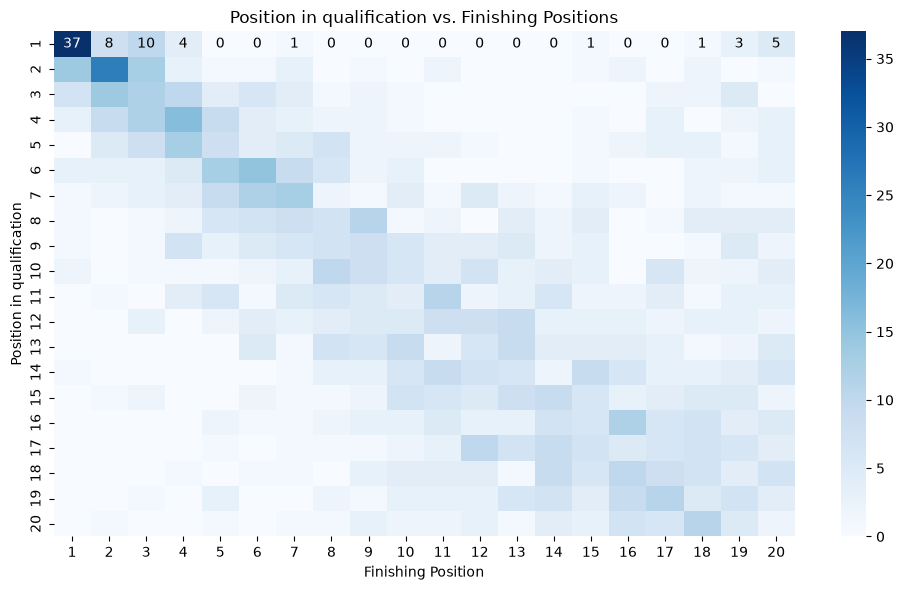

In [217]:
plot_data = results[["grid_position", "finish_position"]].copy()
plot_data["grid_position"] = plot_data["grid_position"].astype(int)
plot_data["finish_position"] = plot_data["finish_position"].astype(int)

heatmap_data = pd.crosstab(
    plot_data["grid_position"],
    plot_data["finish_position"]
).reindex(index=range(1, 21), columns=range(1, 21), fill_value=0)

plt.figure(figsize=(10, 6))
ax =sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,
    fmt="d",
    cbar=True,
    linewidths= 0
)

for col, value in enumerate(heatmap_data.iloc[0]):
    ax.text(
        col + 0.5,
        0.5,
        int(value),
        ha="center",
        va="center",
        color="white" if value > heatmap_data.values.max() / 2 else "black"
    )

plt.title("Position in qualification vs. Finishing Positions")
plt.xlabel("Finishing Position")
plt.ylabel("Position in qualification") 
plt.tight_layout()
plt.show()


It is can be seen that position in qualification very often determines your finishing position. Sometimes it is as important as the race

*The next very interesting point to look at is which of the drivers has the highest realisation of its grid position* 

In [218]:
results_analysis = results.copy()
results_analysis["avg_gained_positions"] =results_analysis.groupby("driver_id")["grid_position"].transform(lambda x: (x - results_analysis["finish_position"]).mean())

avg_gained_postions_rank = results_analysis[["full_name", "avg_gained_positions"]].drop_duplicates().sort_values(by="avg_gained_positions", ascending=False).head(10)
avg_gained_postions_rank

,full_name,avg_gained_positions
1630,Franco Colapinto,6.000000
1346,Oliver Bearman,4.000000
254,Robert Kubica,2.000000
1132,Liam Lawson,1.600000
891,Logan Sargeant,1.307692
9,Lance Stroll,1.173913
19,Nikita Mazepin,0.666667
748,Nyck De Vries,0.545455
1,Max Verstappen,0.528571
470,Guanyu Zhou,0.416667


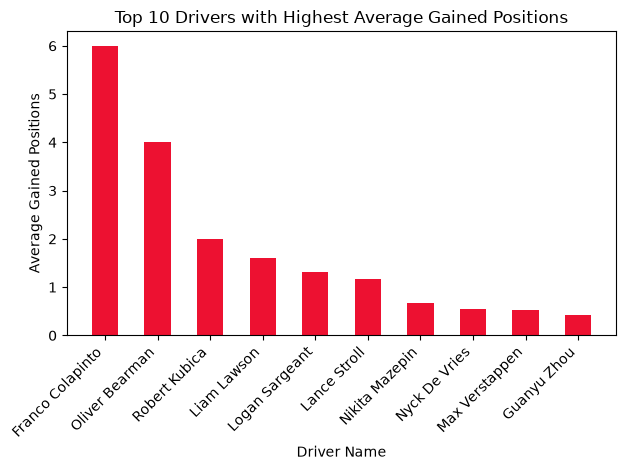

In [219]:
plt.bar(avg_gained_postions_rank["full_name"], avg_gained_postions_rank["avg_gained_positions"], color='#ED1131', width=0.5)
plt.title("Top 10 Drivers with Highest Average Gained Positions")
plt.xlabel("Driver Name")
plt.ylabel("Average Gained Positions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Next we will look at the number of gained points by drivers and then the teams

In [220]:
results_analysis["sum_of_points"] = results_analysis.groupby("driver_id")["points"].transform("sum")
top_gained_points = results_analysis[["full_name","sum_of_points"]].drop_duplicates().sort_values(by="sum_of_points", ascending=False).head(10)
top_gained_points

,full_name,sum_of_points
1,Max Verstappen,1439.5
0,Lewis Hamilton,880.5
4,Sergio Perez,774.0
5,Charles Leclerc,659.0
7,Carlos Sainz,582.5
3,Lando Norris,549.0
13,George Russell,455.0
18,Fernando Alonso,389.0
2,Valtteri Bottas,268.0
12,Esteban Ocon,203.0


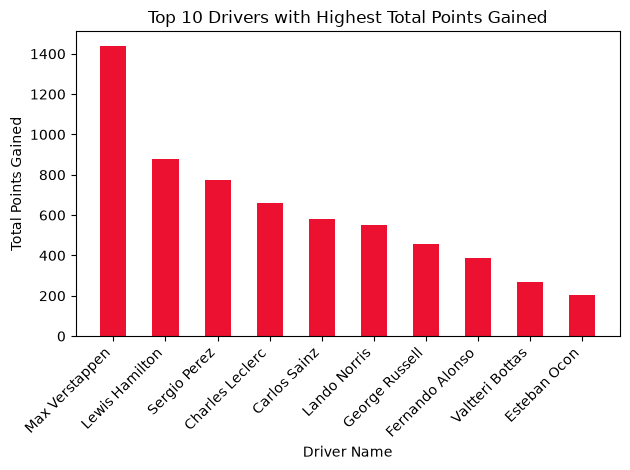

In [221]:
plt.bar(top_gained_points["full_name"], top_gained_points["sum_of_points"], color='#ED1131', width=0.5)
plt.title("Top 10 Drivers with Highest Total Points Gained")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's see how much points did Max Verstappen take from all of the points for these years

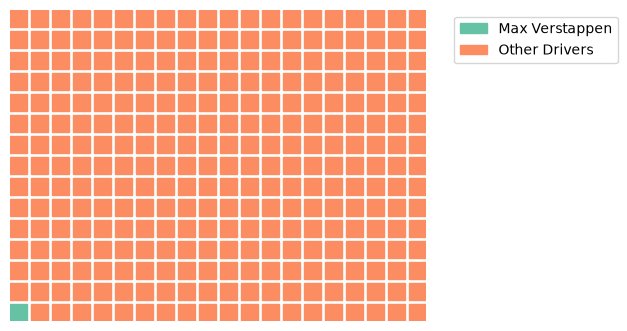

In [222]:
max_points = results_analysis["sum_of_points"].where(results_analysis["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis["sum_of_points"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
)
plt.show()

In [223]:
percentage_max = (max_points / results_analysis["sum_of_points"].sum()) * 100
print(percentage_max)

0.30013875814070345


Although, Max has the highest number of points, it is still 0.3% of all points gained from 2021 to 2024

In [224]:
results_analysis["sum_of_points_constructor"] = results_analysis.groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor = results_analysis[["constructor_name","sum_of_points_constructor"]].drop_duplicates().sort_values(by="sum_of_points_constructor", ascending=False).head(10)
top_gained_points_by_constructor

,constructor_name,sum_of_points_constructor
1,Red Bull Racing,2213.5
0,Mercedes,1538.5
5,Ferrari,1247.5
3,McLaren,859.0
9,Aston Martin,433.0
12,Alpine,419.0
8,AlphaTauri,189.0
10,Alfa Romeo,73.0
13,Williams,59.0
15,Haas F1 Team,43.0


We can see that if we would compare Max Verstappen to the whole teams(excluding his team Red Bull Racing), Max would be on the second place with 99 points difference with Mercedes team. 

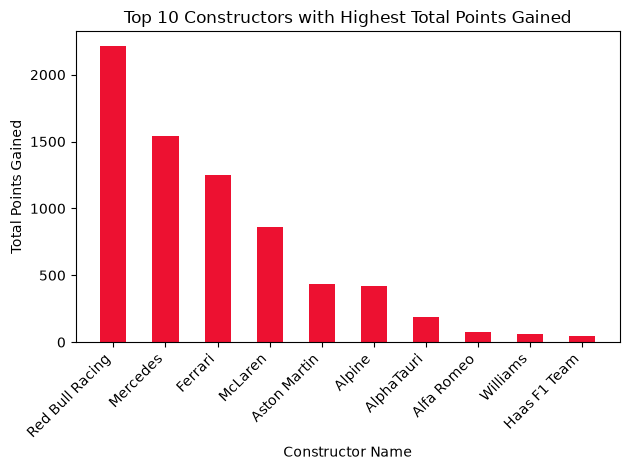

In [225]:
plt.bar(top_gained_points_by_constructor["constructor_name"], top_gained_points_by_constructor["sum_of_points_constructor"], color='#ED1131', width=0.5)
plt.title("Top 10 Constructors with Highest Total Points Gained")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Lets **Max Verstappen** add to the plot

In [ ]:
plt.bar(top_gained_points_by_constructor["constructor_name"], top_gained_points_by_constructor["sum_of_points_constructor"], color='#ED1131', width=0.5)
plt.bar("Max Verstappen", max_points, color='Blue', width=0.5)